In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

df = pd.read_csv("f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']

df = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df[FEATURES].values

print(f"Dataset loaded: {X.shape}")
df.head(3)


Dataset loaded: (5302, 4)


,driver_name,nationality,year,grid,position,points,laps,milliseconds,fastestLapSpeed,statusId,finished,podium
0,Fernando Alonso,Spanish,2010,3.0,1.0,25.0,49,5960396.0,191.706,1,1,1
1,Felipe Massa,Brazilian,2010,2.0,2.0,18.0,49,5976495.0,189.392,1,1,1
2,Lewis Hamilton,British,2010,4.0,3.0,15.0,49,5983578.0,189.665,1,1,1


In [2]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Before scaling — first row:", X[0])
print("After scaling  — first row:", X_scaled[0].round(3))


Before scaling — first row: [  3.     49.     25.    191.706]
After scaling  — first row: [-1.25  -1.188  2.57  -0.644]


In [3]:
km_random = KMeans(
    n_clusters=3,
    init='random',
    n_init=10,
    random_state=42,
    max_iter=300
)
km_random.fit(X_scaled)

df['cluster_random'] = km_random.labels_

print("Step 1 (random init) reproduced:")
print(f"  Inertia      : {km_random.inertia_:.1f}")
print(f"  Silhouette   : {silhouette_score(X_scaled, km_random.labels_):.3f}")
print(f"  Iterations   : {km_random.n_iter_}")
print(f"  Cluster sizes: {dict(pd.Series(km_random.labels_).value_counts().sort_index())}")


Step 1 (random init) reproduced:
  Inertia      : 11116.9
  Silhouette   : 0.289
  Iterations   : 10
  Cluster sizes: {0: np.int64(2209), 1: np.int64(1571), 2: np.int64(1522)}


In [4]:
km_pp = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42,
    max_iter=300
)
km_pp.fit(X_scaled)

df['cluster_pp'] = km_pp.labels_

print("Step 2 (K-Means++ init):")
print(f"  Inertia      : {km_pp.inertia_:.1f}")
print(f"  Silhouette   : {silhouette_score(X_scaled, km_pp.labels_):.3f}")
print(f"  Iterations   : {km_pp.n_iter_}")
print(f"  Cluster sizes: {dict(pd.Series(km_pp.labels_).value_counts().sort_index())}")


Step 2 (K-Means++ init):
  Inertia      : 11116.9
  Silhouette   : 0.289
  Iterations   : 9
  Cluster sizes: {0: np.int64(1522), 1: np.int64(2209), 2: np.int64(1571)}


In [5]:
results_random, results_pp = [], []

for seed in range(20):
    km_r = KMeans(n_clusters=3, init='random', n_init=1,
                  random_state=seed, max_iter=300)
    km_r.fit(X_scaled)
    results_random.append({'inertia': km_r.inertia_, 'iterations': km_r.n_iter_})

    km_p = KMeans(n_clusters=3, init='k-means++', n_init=1,
                  random_state=seed, max_iter=300)
    km_p.fit(X_scaled)
    results_pp.append({'inertia': km_p.inertia_, 'iterations': km_p.n_iter_})

df_r = pd.DataFrame(results_random)
df_p = pd.DataFrame(results_pp)

print(f"{'Metric':<28} {'Random init':>12} {'K-Means++':>12}")
print("-" * 55)
print(f"{'Avg inertia':<28} {df_r['inertia'].mean():>12.1f} {df_p['inertia'].mean():>12.1f}")
print(f"{'Std inertia (consistency)':<28} {df_r['inertia'].std():>12.1f} {df_p['inertia'].std():>12.1f}")
print(f"{'Avg iterations':<28} {df_r['iterations'].mean():>12.1f} {df_p['iterations'].mean():>12.1f}")
print(f"{'Best inertia seen':<28} {df_r['inertia'].min():>12.1f} {df_p['inertia'].min():>12.1f}")
print(f"{'Worst inertia seen':<28} {df_r['inertia'].max():>12.1f} {df_p['inertia'].max():>12.1f}")
print()
print("Lower inertia = tighter clusters = better")
print("Lower std     = more consistent  = less sensitive to random seed")


Metric                        Random init    K-Means++
-------------------------------------------------------
Avg inertia                       11117.1      11117.1
Std inertia (consistency)             0.1          0.1
Avg iterations                       16.1         17.6
Best inertia seen                 11116.9      11116.9
Worst inertia seen                11117.3      11117.2

Lower inertia = tighter clusters = better
Lower std     = more consistent  = less sensitive to random seed


/tmp/ipykernel_52717/2669509768.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(
/tmp/ipykernel_52717/2669509768.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


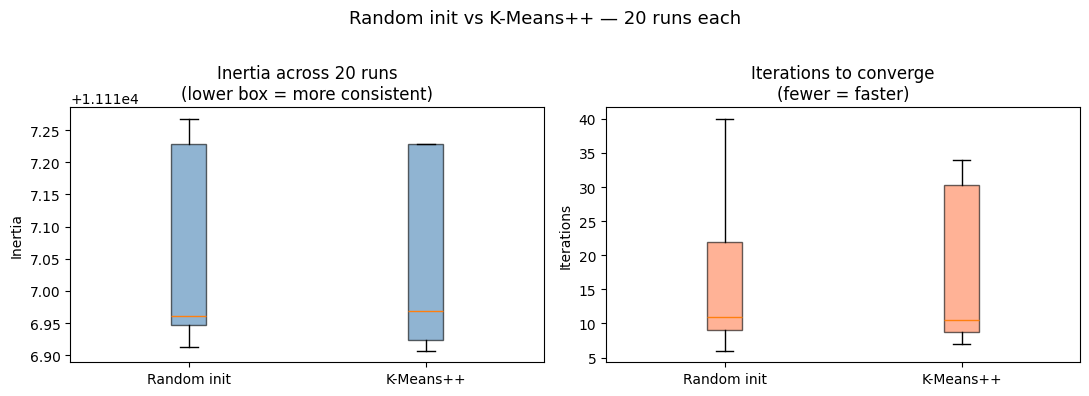

Saved: kmeanspp_boxplots.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.boxplot(
    [df_r['inertia'].values, df_p['inertia'].values],
    labels=['Random init', 'K-Means++'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
ax1.set_title("Inertia across 20 runs\n(lower box = more consistent)")
ax1.set_ylabel("Inertia")

ax2.boxplot(
    [df_r['iterations'].values, df_p['iterations'].values],
    labels=['Random init', 'K-Means++'],
    patch_artist=True,
    boxprops=dict(facecolor='coral', alpha=0.6)
)
ax2.set_title("Iterations to converge\n(fewer = faster)")
ax2.set_ylabel("Iterations")

plt.suptitle("Random init vs K-Means++ — 20 runs each", fontsize=13)
plt.tight_layout()
plt.savefig("kmeanspp_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeanspp_boxplots.png")


In [7]:
cluster_means = df.groupby('cluster_pp')['points'].mean()

label_map = {
    cluster_means.idxmax(): 'Winners',
    cluster_means.idxmin(): 'Backmarkers',
}
for c in [0, 1, 2]:
    if c not in label_map:
        label_map[c] = 'Midfield'

df['cluster_pp_name'] = df['cluster_pp'].map(label_map)

print("Cluster number → name mapping:")
for k, v in label_map.items():
    print(f"  Cluster {k} → {v}  (avg points: {cluster_means[k]:.2f})")


Cluster number → name mapping:
  Cluster 0 → Winners  (avg points: 15.47)
  Cluster 1 → Backmarkers  (avg points: 1.56)
  Cluster 2 → Midfield  (avg points: 2.40)


In [8]:
print("=== K-Means++ Cluster Profiles ===")
profile = df.groupby('cluster_pp_name')[FEATURES + ['podium']].mean().round(2)
print(profile)

print()
print("=== Cluster sizes ===")
print(df['cluster_pp_name'].value_counts())


=== K-Means++ Cluster Profiles ===
                  grid   laps  points  fastestLapSpeed  podium
cluster_pp_name                                               
Backmarkers      13.83  53.07    1.56           211.32    0.00
Midfield         12.90  68.60    2.40           191.05    0.02
Winners           3.96  59.04   15.47           209.96    0.57

=== Cluster sizes ===
cluster_pp_name
Backmarkers    2209
Midfield       1571
Winners        1522
Name: count, dtype: int64


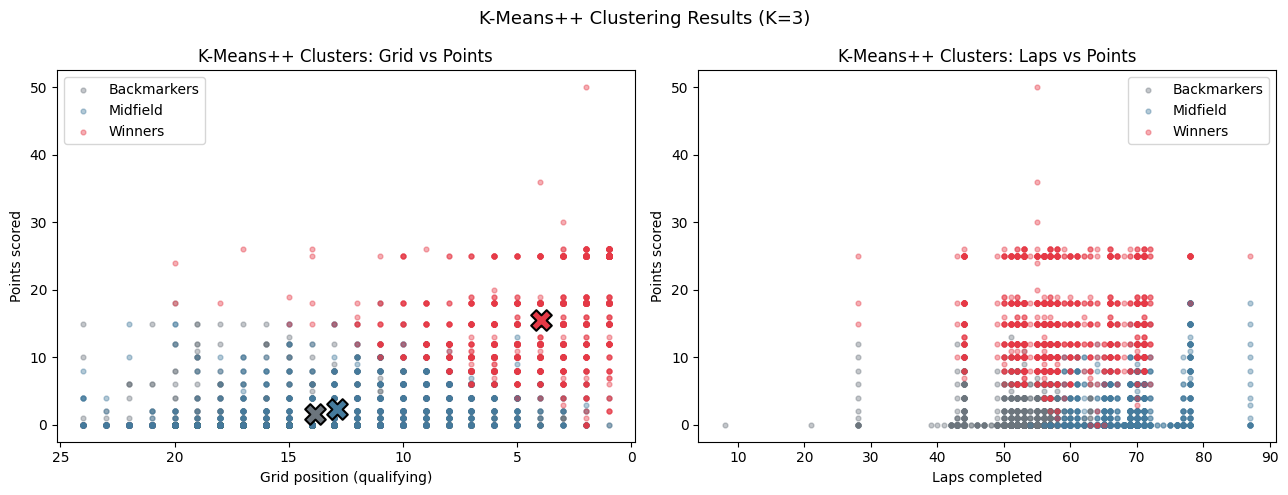

Saved: kmeanspp_clusters.png


In [9]:
colors = {'Winners': '#e63946', 'Midfield': '#457b9d', 'Backmarkers': '#6c757d'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, group in df.groupby('cluster_pp_name'):
    ax.scatter(group['grid'], group['points'],
               color=colors[name], label=name, alpha=0.4, s=12)

centroids_orig = scaler.inverse_transform(km_pp.cluster_centers_)
for i, row in enumerate(centroids_orig):
    name = label_map[i]
    ax.scatter(row[0], row[2], color=colors[name],
               s=220, marker='X', edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel("Grid position (qualifying)")
ax.set_ylabel("Points scored")
ax.set_title("K-Means++ Clusters: Grid vs Points")
ax.invert_xaxis()   # P1 (pole) at the left = top of the grid
ax.legend()

ax2 = axes[1]
for name, group in df.groupby('cluster_pp_name'):
    ax2.scatter(group['laps'], group['points'],
                color=colors[name], label=name, alpha=0.4, s=12)

ax2.set_xlabel("Laps completed")
ax2.set_ylabel("Points scored")
ax2.set_title("K-Means++ Clusters: Laps vs Points")
ax2.legend()

plt.suptitle("K-Means++ Clustering Results (K=3)", fontsize=13)
plt.tight_layout()
plt.savefig("kmeanspp_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kmeanspp_clusters.png")


In [10]:
ars = adjusted_rand_score(df['cluster_random'], df['cluster_pp'])

print(f"Adjusted Rand Score (Random vs K-Means++): {ars:.3f}")
print()
if ars > 0.9:
    print("✓ Score > 0.9 → Both methods found essentially the SAME clusters.")
    print("  This means the Winners/Midfield/Backmarkers structure is genuinely")
    print("  strong in the data — not an accident of initialization.")
else:
    print("The two methods disagree. K-Means++ result is more trustworthy.")

Adjusted Rand Score (Random vs K-Means++): 1.000

✓ Score > 0.9 → Both methods found essentially the SAME clusters.
  This means the Winners/Midfield/Backmarkers structure is genuinely
  strong in the data — not an accident of initialization.
